# 04

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [2]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = 'final_figure'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [3]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [4]:
real_variant_dfs = []
synth_variant_dfs = []

for key, path in VARIANT_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_variant_dfs.append(lf)
    else:
        real_variant_dfs.append(lf)

df_real = pl.concat(real_variant_dfs).collect()
df_synth = pl.concat(synth_variant_dfs).collect()

df_hi_variants = df_real.filter(pl.col('source') == 'clingen')
df_bg_variants = df_real.filter(pl.col('source') == 'background')
df_hi_synth_variants = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth_variants = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi_variants.height} variants')
print(f'Background: {df_bg_variants.height} variants')
print(f'ClinGen HI (Synth): {df_hi_synth_variants.height} variants')
print(f'Background (Synth): {df_bg_synth_variants.height} variants')

ClinGen HI: 1743183 variants
Background: 1999142 variants
ClinGen HI (Synth): 1556962 variants
Background (Synth): 1788286 variants


# Extra paths

In [5]:
GENE_CHARACTERISTICS = "/Users/markus/in-silico-vg-analysis/07_permutations/gene_characteristics.tsv"

Mann-Whitney U (HI > BG): U=61126, P=7.79e-03
Median rare fraction  HI: 0.251  BG: 0.208
[save_plot] Saved: final_figure_04_plot6_AF_variance_distribution_16032026_2058.pdf
[save_plot] Saved: final_figure_04_plot6_AF_variance_distribution_16032026_2058.svg


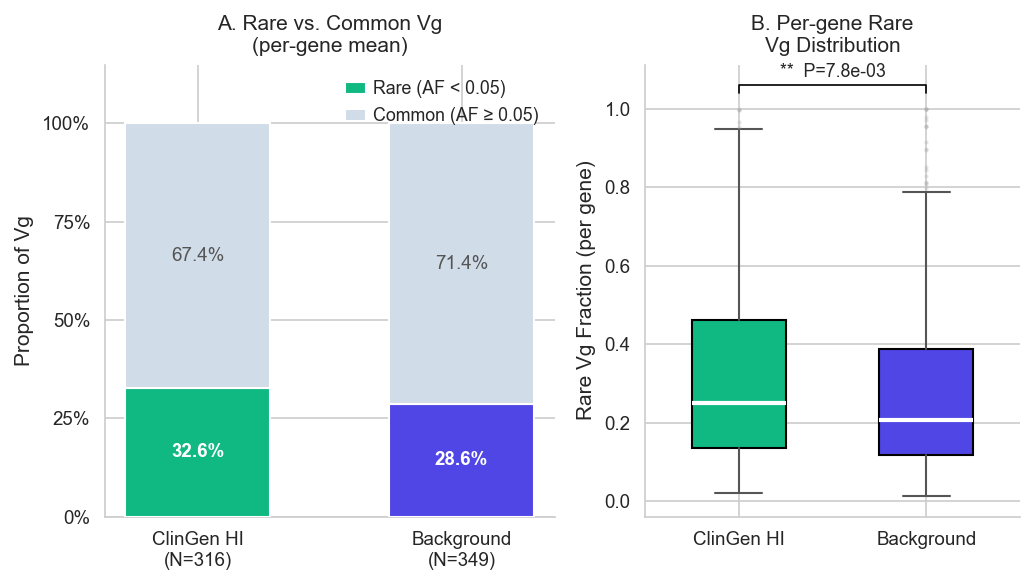

In [6]:
# ─── Plot 6: Allele Frequency Variance Distribution ──────────────────────────
# 100% stacked bar + per-gene distribution: rare vs. common Vg proportion
# Compares ClinGen HI vs. Background

import numpy as np

hi_pd = df_hi.to_pandas()
bg_pd = df_bg.to_pandas()

hi_total = hi_pd['vg_rare'] + hi_pd['vg_common']
bg_total = bg_pd['vg_rare'] + bg_pd['vg_common']

hi_mask = hi_total > 0
bg_mask = bg_total > 0

hi_rare_frac = (hi_pd.loc[hi_mask, 'vg_rare'] / hi_total[hi_mask]).values
bg_rare_frac = (bg_pd.loc[bg_mask, 'vg_rare'] / bg_total[bg_mask]).values

u_stat, pval = stats.mannwhitneyu(hi_rare_frac, bg_rare_frac, alternative='greater')
print(f"Mann-Whitney U (HI > BG): U={u_stat:.0f}, P={pval:.2e}")
print(f"Median rare fraction  HI: {np.median(hi_rare_frac):.3f}  BG: {np.median(bg_rare_frac):.3f}")

# Colours: dark for rare, light for common
RARE_HI  = SOURCE_PALETTE['clingen']
RARE_BG  = SOURCE_PALETTE['background']
COMMON_C = '#d0dce8'

hi_rare_mean   = float(np.mean(hi_rare_frac))
bg_rare_mean   = float(np.mean(bg_rare_frac))

n_hi = int(hi_mask.sum())
n_bg = int(bg_mask.sum())
labels = [f'ClinGen HI\n(N={n_hi})', f'Background\n(N={n_bg})']
rare_means   = [hi_rare_mean, bg_rare_mean]
common_means = [1 - hi_rare_mean, 1 - bg_rare_mean]

def fmt_pval(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

with autosave('04_plot6_AF_variance_distribution', notebook=NOTEBOOK_NAME):
    fig, (ax_bar, ax_box) = plt.subplots(1, 2, figsize=(7, 4),
                                          gridspec_kw={'width_ratios': [1.2, 1]})

    # ── Panel A: 100% stacked bar ─────────────────────────────────────────────
    x = np.arange(len(labels))
    bw = 0.55
    ax_bar.bar(x, rare_means, bw, color=[RARE_HI, RARE_BG], zorder=3, label='Rare (AF < 0.05)')
    ax_bar.bar(x, common_means, bw, bottom=rare_means, color=COMMON_C, zorder=3, label='Common (AF \u2265 0.05)')

    for xi, rm in enumerate(rare_means):
        ax_bar.text(xi, rm / 2, f'{rm*100:.1f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        ax_bar.text(xi, rm + (1 - rm) / 2, f'{(1-rm)*100:.1f}%',
                    ha='center', va='center', fontsize=9, color='#555555')

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(labels, fontsize=9)
    ax_bar.set_ylabel('Proportion of Vg', fontsize=10)
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax_bar.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=9)
    ax_bar.set_title('A. Rare vs. Common Vg\n(per-gene mean)', fontsize=10)
    ax_bar.legend(frameon=False, fontsize=8.5, handlelength=1.2, handletextpad=0.4, loc='upper right')
    sns.despine(ax=ax_bar)

    # ── Panel B: per-gene rare fraction distributions ─────────────────────────
    bp = ax_box.boxplot([hi_rare_frac, bg_rare_frac], positions=[0, 1], widths=0.5,
                        patch_artist=True,
                        medianprops=dict(color='white', lw=2),
                        whiskerprops=dict(color='#555555', lw=1),
                        capprops=dict(color='#555555', lw=1),
                        flierprops=dict(marker='o', ms=2, alpha=0.3,
                                        mfc='#aaaaaa', mew=0))
    bp['boxes'][0].set_facecolor(RARE_HI)
    bp['boxes'][1].set_facecolor(RARE_BG)

    y_top = max(hi_rare_frac.max(), bg_rare_frac.max())
    y_ann = y_top * 1.04
    ax_box.plot([0, 0, 1, 1], [y_ann, y_ann * 1.02, y_ann * 1.02, y_ann], 'k-', lw=0.8)
    ax_box.text(0.5, y_ann * 1.03,
                f'{fmt_pval(pval)}  P={pval:.1e}',
                ha='center', va='bottom', fontsize=8.5, linespacing=1.5)

    ax_box.set_xticks([0, 1])
    ax_box.set_xticklabels(['ClinGen HI', 'Background'], fontsize=9)
    ax_box.set_ylabel('Rare Vg Fraction (per gene)', fontsize=10)
    ax_box.set_title('B. Per-gene Rare\nVg Distribution', fontsize=10)
    ax_box.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax_box)

    plt.tight_layout()


[save_plot] Saved: final_figure_04_plot7_architecture_distributions_16032026_2058.pdf
[save_plot] Saved: final_figure_04_plot7_architecture_distributions_16032026_2058.svg


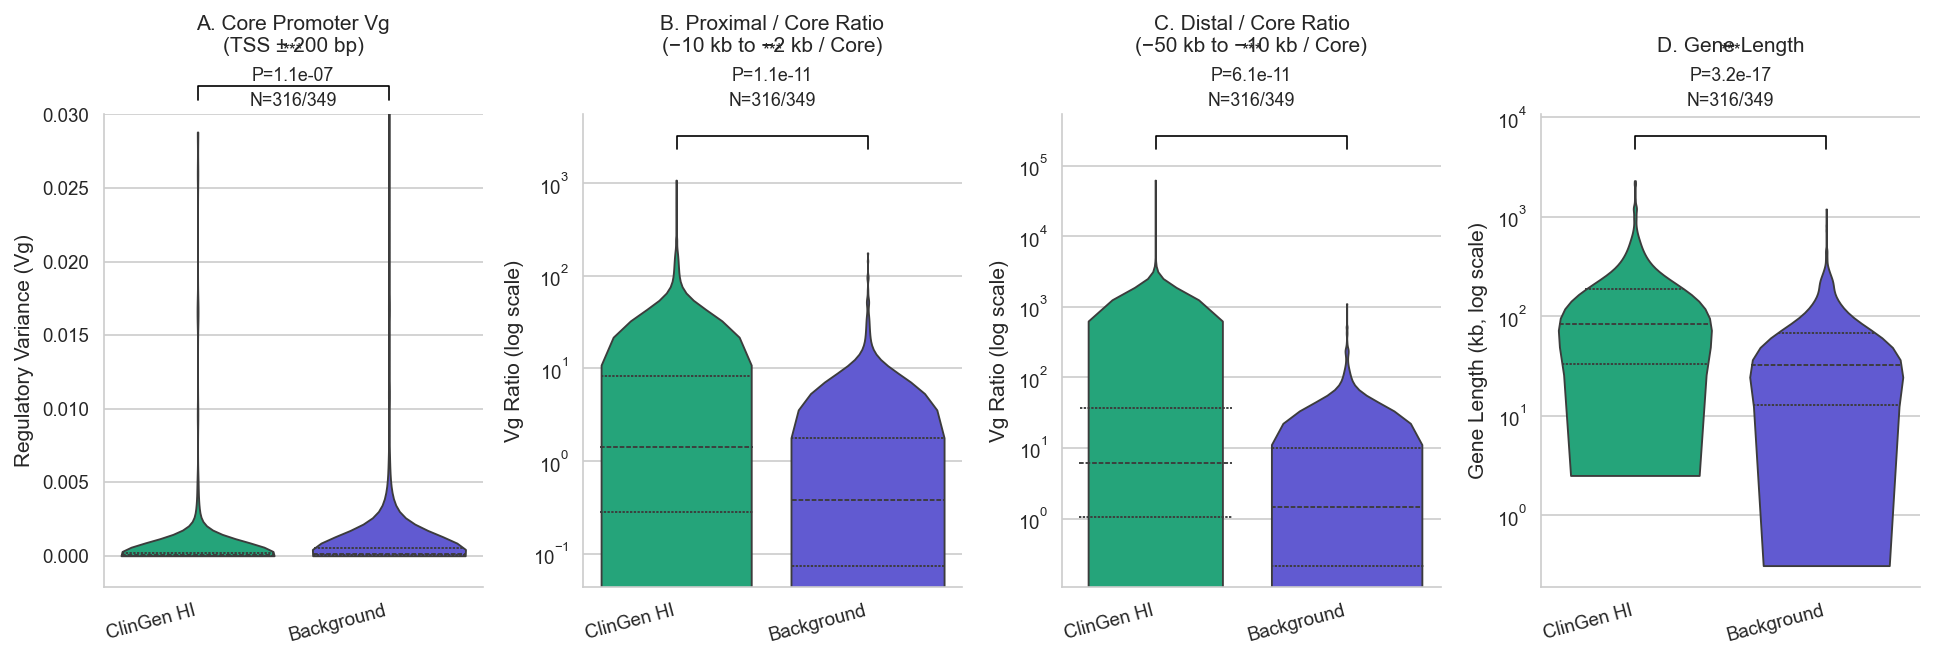

In [7]:
# ─── Plot 7: Regulatory Architecture Distributions ───────────────────────────
# 4-panel: A) Core Vg  B) Proximal/Core ratio  C) Distal/Core ratio  D) Gene Length
# Compares ClinGen HI vs. Background  (violin + quartile lines)
# Reference: 04_ESHG_abstract/03_architecture_distributions.ipynb

import warnings

def _build_arch_df(df_polars, label):
    d = df_polars.to_pandas()
    vg_core = d['vg_promoter_core'].values
    vg_prox = d['vg_proximal_upstream'].values
    vg_dist = d['vg_distal_upstream'].values
    vg_core_safe = np.where(vg_core == 0, 1e-10, vg_core)
    return {
        'source':         label,
        'vg_core':        vg_core,
        'ratio_proximal': vg_prox / vg_core_safe,
        'ratio_distal':   vg_dist / vg_core_safe,
        'gene_length_kb': d['genomic_length'].values / 1e3,
    }

hi_arch = _build_arch_df(df_hi, 'ClinGen HI')
bg_arch = _build_arch_df(df_bg, 'Background')

import pandas as pd
arch_df = pd.DataFrame(
    {k: np.concatenate([hi_arch[k], bg_arch[k]])
     for k in hi_arch if k != 'source'}
)
arch_df['source'] = (['ClinGen HI'] * len(hi_arch['vg_core']) +
                     ['Background'] * len(bg_arch['vg_core']))

palette = {
    'ClinGen HI': SOURCE_PALETTE['clingen'],
    'Background': SOURCE_PALETTE['background'],
}

configs = [
    ('vg_core',        'A. Core Promoter Vg\n(TSS \u00b1 200 bp)',              'Regulatory Variance (Vg)',   False),
    ('ratio_proximal', 'B. Proximal / Core Ratio\n(\u221210 kb to \u22122 kb / Core)', 'Vg Ratio (log scale)',        True),
    ('ratio_distal',   'C. Distal / Core Ratio\n(\u221250 kb to \u221210 kb / Core)', 'Vg Ratio (log scale)',        True),
    ('gene_length_kb', 'D. Gene Length',                                           'Gene Length (kb, log scale)', True),
]

def fmt_pval(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

with autosave('04_plot7_architecture_distributions', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))

    for ax, (metric, title, ylab, is_log) in zip(axes, configs):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            sns.violinplot(data=arch_df, x='source', y=metric,
                           hue='source', palette=palette,
                           order=['ClinGen HI', 'Background'],
                           hue_order=['ClinGen HI', 'Background'],
                           inner='quartile', linewidth=0.9, cut=0,
                           legend=False, ax=ax)

        if is_log:
            ax.set_yscale('log')

        hi_vals = hi_arch[metric]
        bg_vals = bg_arch[metric]
        u, p = stats.mannwhitneyu(hi_vals, bg_vals, alternative='two-sided')

        # Panel A intentionally truncates extreme tail to improve readability.
        if metric == 'vg_core':
            ax.set_ylim(top=0.03)

        # annotation bar
        ys = ax.get_ylim()
        y_top = ys[1]
        if is_log:
            import math
            y_ann  = y_top * 10 ** (0.06 * math.log10(y_top / ys[0]))
            y_line = y_top * 10 ** (0.03 * math.log10(y_top / ys[0]))
        else:
            span  = ys[1] - ys[0]
            y_ann  = ys[1] + 0.06 * span
            y_line = ys[1] + 0.03 * span

        ax.plot([0, 0, 1, 1], [y_line, y_ann, y_ann, y_line], 'k-', lw=0.8,
                transform=ax.get_xaxis_transform() if False else ax.transData,
                clip_on=False)
        ax.annotate(f'{fmt_pval(p)}\nP={p:.1e}\nN={len(hi_vals)}/{len(bg_vals)}',
                    xy=(0.5, 1.01), xycoords='axes fraction',
                    ha='center', va='bottom', fontsize=8.5, linespacing=1.5)

        ax.set_title(title, fontsize=10, pad=30)
        ax.set_xlabel('')
        ax.set_ylabel(ylab, fontsize=10)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['ClinGen HI', 'Background'], fontsize=9, rotation=15, ha='right')
        ax.tick_params(axis='y', labelsize=9)
        sns.despine(ax=ax)

    plt.tight_layout()

In [8]:

# 3b) Regional Vg summary collapsed to Promoter / Upstream / Downstream
region_3_df = plot_df.copy()
region_3_df['vg_upstream_total'] = region_3_df['vg_region_proximal_upstream'] + region_3_df['vg_region_distal_upstream']
region_3_df['vg_downstream_total'] = region_3_df['vg_region_down_proximal'] + region_3_df['vg_region_down_distal']

region_3_long = region_3_df.melt(
    id_vars=['source_label'],
    value_vars=[
        'vg_region_promoter_core',
        'vg_upstream_total',
        'vg_downstream_total',
    ],
    var_name='region_group',
    value_name='region_vg',
)

region_3_labels = {
    'vg_region_promoter_core': 'Promoter (TSS±200bp)',
    'vg_upstream_total': 'Upstream (-200 bp to -10 kb)',
    'vg_downstream_total': 'Downstream (+200 bp to +10 kb)',
}
region_3_order = [
    'Promoter (TSS±200bp)',
    'Upstream (-200 bp to -10 kb)',
    'Downstream (+200 bp to +10 kb)',
]
region_3_long['region_group'] = region_3_long['region_group'].map(region_3_labels)

# ── Build per-gene CI data for real datasets (per AGENTS.md: CIs on real only) ───
# CI columns used:
#   Promoter:   vg_promoter_core_CI_{p05,mean,p95}
#   Upstream:   per-gene sum of vg_proximal_upstream_CI_* + vg_distal_upstream_CI_*
#   Downstream: per-gene sum of vg_down_proximal_CI_*   + vg_down_distal_CI_*
# All CI columns are from the real (gnomAD) dataframes (df_bg, df_hi).

def _region3_ci(df_src):
    """Returns dict: region_label -> (med_p05, med_mean, med_p95)"""
    ci_data = {}

    # Promoter
    promo_cols = ['vg_promoter_core_CI_p05', 'vg_promoter_core_CI_mean', 'vg_promoter_core_CI_p95']
    if all(c in df_src.columns for c in promo_cols):
        ci_pd = df_src.select(promo_cols).to_pandas().dropna()
        ci_data['Promoter (TSS±200bp)'] = (
            ci_pd['vg_promoter_core_CI_p05'].median(),
            ci_pd['vg_promoter_core_CI_mean'].median(),
            ci_pd['vg_promoter_core_CI_p95'].median(),
        )

    # Upstream = proximal_upstream + distal_upstream, summed per gene
    up_cols = [
        'vg_proximal_upstream_CI_p05', 'vg_proximal_upstream_CI_mean', 'vg_proximal_upstream_CI_p95',
        'vg_distal_upstream_CI_p05',   'vg_distal_upstream_CI_mean',   'vg_distal_upstream_CI_p95',
    ]
    if all(c in df_src.columns for c in up_cols):
        ci_pd = df_src.select(up_cols).to_pandas().dropna()
        ci_data['Upstream (-200 bp to -10 kb)'] = (
            (ci_pd['vg_proximal_upstream_CI_p05'] + ci_pd['vg_distal_upstream_CI_p05']).median(),
            (ci_pd['vg_proximal_upstream_CI_mean'] + ci_pd['vg_distal_upstream_CI_mean']).median(),
            (ci_pd['vg_proximal_upstream_CI_p95'] + ci_pd['vg_distal_upstream_CI_p95']).median(),
        )

    # Downstream = down_proximal + down_distal, summed per gene
    dn_cols = [
        'vg_down_proximal_CI_p05', 'vg_down_proximal_CI_mean', 'vg_down_proximal_CI_p95',
        'vg_down_distal_CI_p05',   'vg_down_distal_CI_mean',   'vg_down_distal_CI_p95',
    ]
    if all(c in df_src.columns for c in dn_cols):
        ci_pd = df_src.select(dn_cols).to_pandas().dropna()
        ci_data['Downstream (+200 bp to +10 kb)'] = (
            (ci_pd['vg_down_proximal_CI_p05'] + ci_pd['vg_down_distal_CI_p05']).median(),
            (ci_pd['vg_down_proximal_CI_mean'] + ci_pd['vg_down_distal_CI_mean']).median(),
            (ci_pd['vg_down_proximal_CI_p95'] + ci_pd['vg_down_distal_CI_p95']).median(),
        )

    return ci_data

ci_bg_r3 = _region3_ci(df_bg)
ci_hi_r3 = _region3_ci(df_hi)
CI_REAL_R3 = {
    'Background_Gnomad': ci_bg_r3,
    'ClinGen_HI_Gnomad': ci_hi_r3,
}

CI_COLOR  = '#FFD700'
CI_ECOLOR = '#CC8800'

with autosave('AF_Cutoff_Regional_Promoter_Upstream_Downstream_Boxplot'):
    fig, ax = plt.subplots(figsize=(12.5, 6.2), constrained_layout=True)
    sns.boxplot(
        data=region_3_long,
        x='source_label',
        y='region_vg',
        hue='region_group',
        order=source_label_order,
        hue_order=region_3_order,
        showfliers=True,
        flierprops={'marker': 'o', 'markersize': 2.8, 'alpha': 0.65},
        medianprops={'color': 'white', 'linewidth': 2.0},
        ax=ax,
    )
    ax.set_yscale('log')

    # ── Overlay Monte Carlo CIs (real datasets only) ──────────────────────────
    # Hue offsets: with seaborn default width=0.8 and 3 hue groups,
    # offset_i = (i - (n-1)/2) * (0.8/n)
    n_hues = len(region_3_order)
    hue_offsets = [(i - (n_hues - 1) / 2) * (0.8 / n_hues) for i in range(n_hues)]

    ci_legend_added = False
    for src_label, ci_dict in CI_REAL_R3.items():
        if src_label not in source_label_order:
            continue
        x_base = source_label_order.index(src_label)
        for hue_idx, region_label in enumerate(region_3_order):
            if region_label not in ci_dict:
                print(f'  [skip CI] {src_label} / {region_label}: CI columns not found')
                continue
            med_p05, med_mean, med_p95 = ci_dict[region_label]
            x_pos = x_base + hue_offsets[hue_idx]
            label_ci = 'Median gene CI (90%, MC)' if not ci_legend_added else '_nolegend_'
            ax.errorbar(
                x_pos, med_mean,
                yerr=[[med_mean - med_p05], [med_p95 - med_mean]],
                fmt='D',
                color=CI_COLOR,
                ecolor=CI_ECOLOR,
                elinewidth=2.0,
                capsize=6,
                capthick=2.0,
                markersize=7,
                markeredgecolor='black',
                markeredgewidth=1.2,
                zorder=15,
                label=label_ci,
            )
            ci_legend_added = True
            print(
                f'{src_label} / {region_label}: '
                f'median CI = [{med_p05:.3e}, {med_p95:.3e}]  (mean={med_mean:.3e})'
            )

    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Predicted genetic variance, Vg (unitless)', fontsize=10)
    ax.set_title('Predicted Vg divided into promoter / upstream / downstream', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    handles, labels_leg = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels_leg, title='Regions', frameon=True)


NameError: name 'plot_df' is not defined

Mann-Whitney U (HI > BG): U=58225, P=3.30e-03
Median enhancers  HI: 24.0  BG: 19.0
[save_plot] Saved: final_figure_04_plot8_enhancer_count_validation_14032026_1520.pdf
[save_plot] Saved: final_figure_04_plot8_enhancer_count_validation_14032026_1520.svg


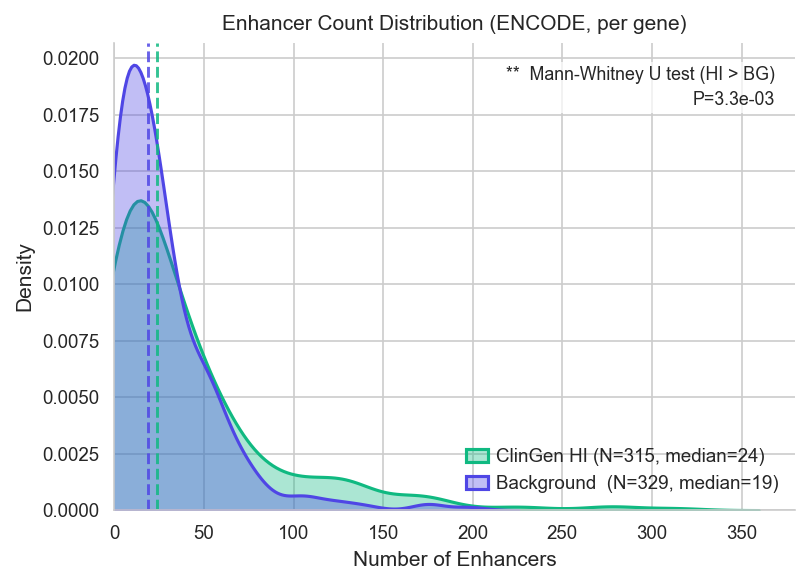

In [ ]:
# ─── Plot 8: Enhancer Count Validation (ENCODE num_enh) ──────────────────────
# KDE comparison of enhancer counts between ClinGen HI and Background
# with median lines and Mann-Whitney test

hi_enh = df_hi['num_enh'].to_numpy().astype(float)
bg_enh = df_bg['num_enh'].to_numpy().astype(float)

# Drop NaN
hi_enh = hi_enh[~np.isnan(hi_enh)]
bg_enh = bg_enh[~np.isnan(bg_enh)]

u_stat, pval = stats.mannwhitneyu(hi_enh, bg_enh, alternative='greater')
print(f'Mann-Whitney U (HI > BG): U={u_stat:.0f}, P={pval:.2e}')
print(f'Median enhancers  HI: {np.median(hi_enh):.1f}  BG: {np.median(bg_enh):.1f}')

col_hi = SOURCE_PALETTE['clingen']
col_bg = SOURCE_PALETTE['background']

def fmt_pval(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

with autosave('04_plot8_enhancer_count_validation', notebook=NOTEBOOK_NAME):
    fig, ax = plt.subplots(figsize=(5.5, 4))

    sns.kdeplot(hi_enh, ax=ax, color=col_hi, fill=True, alpha=0.35, linewidth=1.5,
                label=f'ClinGen HI (N={len(hi_enh)}, median={np.median(hi_enh):.0f})')
    sns.kdeplot(bg_enh, ax=ax, color=col_bg, fill=True, alpha=0.35, linewidth=1.5,
                label=f'Background  (N={len(bg_enh)}, median={np.median(bg_enh):.0f})')

    # Median lines
    for vals, col in [(hi_enh, col_hi), (bg_enh, col_bg)]:
        ax.axvline(np.median(vals), color=col, lw=1.4, ls='--', alpha=0.85)

    # Significance annotation near the top
    ax.text(0.97, 0.95,
            f"{fmt_pval(pval)}  Mann-Whitney U test (HI > BG)\nP={pval:.1e}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, linespacing=1.5,
            bbox=dict(facecolor='white', alpha=0.7, pad=2, edgecolor='none'))

    ax.set_xlabel('Number of Enhancers', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title('Enhancer Count Distribution (ENCODE, per gene)', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.legend(frameon=False, fontsize=9, handlelength=1.2, handletextpad=0.4)
    ax.set_xlim(left=0)  # Enhancer count cannot be negative
    sns.despine(ax=ax)

    plt.tight_layout()
